# Restaurant Pricing & Promotion Analytics — Final Model

**Purpose:** A reproducible, decision-support analytics model for menu pricing, competitive positioning, and promotion planning.

**Source data**
- Company menu master: 10 items × 15 original variables from the supplied Excel workbook.
- Competitor benchmark: The Oasis Rooftop Lounge profile supplied with the project.
- No external data is introduced.

### What this model does
1. Validates and cleans the menu master.
2. Profiles price, popularity, preparation time, calories, and menu mix.
3. Quantifies price–popularity association without implying causality.
4. Benchmarks only **comparable category/segment levels** against the supplied competitor corridors.
5. Converts competitor seasonal/promotion mechanics into clearly attributed benchmark observations.
6. Produces transparent item-level test hypotheses and a rule-based decision-support index.
7. Produces a presentation-ready management summary and exports all analytical tables.

### Critical limitation
The company dataset is a **10-row menu master**, not transaction history. It contains no units sold, revenue by item/date, discounts, promotion exposure, footfall/covers, channel, or unit cost. Therefore this notebook does **not** estimate causal price elasticity, demand curves, or profit-maximizing prices. Any test priority is a hypothesis for controlled measurement, not a prediction of sales uplift.


<div style="font-family:Arial,sans-serif;">
## 1A. Business Model & Commercial Logic

### Business model evidenced by the supplied data
The company operates a **menu-led B2C restaurant model**. Revenue is generated through customer purchases of food and beverage items across multiple menu categories.

**Commercial logic**

**Menu assortment → Customer choice → Item purchase → Revenue**

The management layer is:

**Price + Promotion + Seasonality + Channel + Menu Mix → Demand → Revenue → Margin**

Only the menu/product side is currently observed. Transaction-level demand and margin inputs are not available.

### Business-analysis implication
Pricing and promotions should be treated as **controlled commercial experiments**, not one-time price decisions.
</div>

## 1. Environment and reproducibility


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Environment ready.")


Environment ready.


<div style="font-family:Arial,sans-serif;">

# Restaurant Pricing & Promotion Analytics
## Business Analyst Decision-Support Model

**Executive purpose**
This model converts the supplied restaurant menu master and competitor profile into a structured pricing and promotion decision framework.

**Business questions**
1. What is the current menu and price architecture?
2. What patterns exist across price, popularity and categories?
3. How is the supplied competitor using seasonal pricing and promotions?
4. Where are there defensible areas for controlled pricing or promotion tests?
5. What additional data is required before causal pricing or profit-optimisation decisions?

**Executive conclusion:** The company has a diversified menu-led B2C restaurant model with a ₹40–₹550 menu price range and high average menu popularity. The available data supports descriptive analytics, competitive benchmarking and experiment design, but not causal price elasticity, demand forecasting or profit-optimal pricing. The appropriate management cycle is **test → measure → learn → scale**.
</div>

## 2. Load the supplied company data

The source workbook is embedded below so the notebook is **self-contained**. No upload, file path, or manual code edit is required.


In [ ]:
# Professional analytical styling
import matplotlib as mpl
mpl.rcParams.update({"font.family":"DejaVu Sans","font.size":10,"axes.titlesize":14,"axes.labelsize":10,"xtick.labelsize":9,"ytick.labelsize":9,"figure.dpi":120,"axes.spines.top":False,"axes.spines.right":False,"axes.titleweight":"bold"})
print("Professional analytical styling loaded.")

In [2]:
# Source: Pricing & Promotion - Jaipur Restaurant Cuisine Pricing.xlsx
company_records = [
  {
    "item_id": "NID-201",
    "item_name": "Dal Makhani (Full)",
    "category": "Main Course",
    "sub_category": "Makhani",
    "description": "Slow-cooked black lentils with creamy butter.",
    "price_inr": 340,
    "spice_level": "Mild",
    "dietary_indicator": "Veg",
    "portion_size": "Full",
    "calories_kcal": 450,
    "allergens": "Dairy",
    "preparation_time_mins": 25,
    "chef_special": "Yes",
    "popularity_rating": 4.9,
    "primary_ingredients": "Black Lentils, Cream, Butter"
  },
  {
    "item_id": "NID-202",
    "item_name": "Butter Naan",
    "category": "Breads & Rice",
    "sub_category": "Naan",
    "description": "Leavened clay-oven bread slathered with fresh butter.",
    "price_inr": 70,
    "spice_level": None,
    "dietary_indicator": "Veg",
    "portion_size": "Single",
    "calories_kcal": 220,
    "allergens": "Gluten, Dairy",
    "preparation_time_mins": 8,
    "chef_special": "No",
    "popularity_rating": 4.8,
    "primary_ingredients": "Refined Flour, Butter"
  },
  {
    "item_id": "NID-203",
    "item_name": "Garlic Naan",
    "category": "Breads & Rice",
    "sub_category": "Naan",
    "description": "Clay-oven bread infused with minced garlic and butter.",
    "price_inr": 85,
    "spice_level": None,
    "dietary_indicator": "Veg",
    "portion_size": "Single",
    "calories_kcal": 230,
    "allergens": "Gluten, Dairy",
    "preparation_time_mins": 8,
    "chef_special": "No",
    "popularity_rating": 4.7,
    "primary_ingredients": "Refined Flour, Garlic, Butter"
  },
  {
    "item_id": "NID-204",
    "item_name": "Kadhai Paneer (Full)",
    "category": "Main Course",
    "sub_category": "Curry",
    "description": "Cottage cheese cubes tossed with bell peppers in a spicy tomato gravy.",
    "price_inr": 360,
    "spice_level": "Spicy",
    "dietary_indicator": "Veg",
    "portion_size": "Full",
    "calories_kcal": 410,
    "allergens": "Dairy",
    "preparation_time_mins": 18,
    "chef_special": "No",
    "popularity_rating": 4.5,
    "primary_ingredients": "Paneer, Capsicum, Spices"
  },
  {
    "item_id": "NID-205",
    "item_name": "Murgh Dewan-e-Khas",
    "category": "Main Course",
    "sub_category": "Curry",
    "description": "Rich Mughlai chicken curry prepared with a saffron almond paste.",
    "price_inr": 490,
    "spice_level": "Mild",
    "dietary_indicator": "Non-Veg",
    "portion_size": "Full",
    "calories_kcal": 580,
    "allergens": "Dairy, Nuts",
    "preparation_time_mins": 22,
    "chef_special": "Yes",
    "popularity_rating": 4.9,
    "primary_ingredients": "Chicken, Saffron, Almonds"
  },
  {
    "item_id": "NID-206",
    "item_name": "Mutton Rogan Josh",
    "category": "Main Course",
    "sub_category": "Curry",
    "description": "Traditional Kashmiri style lamb curry cooked with intense spices.",
    "price_inr": 550,
    "spice_level": "Spicy",
    "dietary_indicator": "Non-Veg",
    "portion_size": "Full",
    "calories_kcal": 610,
    "allergens": None,
    "preparation_time_mins": 25,
    "chef_special": "Yes",
    "popularity_rating": 4.8,
    "primary_ingredients": "Mutton, Kashmiri Chilli, Yogurt"
  },
  {
    "item_id": "NID-207",
    "item_name": "Veg Dum Biryani",
    "category": "Breads & Rice",
    "sub_category": "Biryani",
    "description": "Fragrant basmati rice layered with vegetables and slow-cooked on dum.",
    "price_inr": 310,
    "spice_level": "Medium",
    "dietary_indicator": "Veg",
    "portion_size": "Full",
    "calories_kcal": 520,
    "allergens": "Dairy, Gluten",
    "preparation_time_mins": 20,
    "chef_special": "No",
    "popularity_rating": 4.4,
    "primary_ingredients": "Basmati Rice, Mixed Veg, Spices"
  },
  {
    "item_id": "NID-208",
    "item_name": "Shahi Tukda",
    "category": "Desserts & Beverages",
    "sub_category": "Kheer",
    "description": "Deep-fried bread soaked in condensed milk with cardamom and nuts.",
    "price_inr": 180,
    "spice_level": None,
    "dietary_indicator": "Veg",
    "portion_size": "Single",
    "calories_kcal": 420,
    "allergens": "Dairy, Gluten, Nuts",
    "preparation_time_mins": 15,
    "chef_special": "Yes",
    "popularity_rating": 4.7,
    "primary_ingredients": "Bread, Milk, Saffron, Nuts"
  },
  {
    "item_id": "NID-209",
    "item_name": "Gulab Jamun (2 Pcs)",
    "category": "Desserts & Beverages",
    "sub_category": "Kheer",
    "description": "Golden fried milk-solid dumplings dipped in rose-scented sugar syrup.",
    "price_inr": 110,
    "spice_level": None,
    "dietary_indicator": "Veg",
    "portion_size": "Single",
    "calories_kcal": 310,
    "allergens": "Dairy, Gluten",
    "preparation_time_mins": 10,
    "chef_special": "No",
    "popularity_rating": 4.6,
    "primary_ingredients": "Khoya, Sugar Syrup"
  },
  {
    "item_id": "NID-210",
    "item_name": "Tandoori Roti",
    "category": "Breads & Rice",
    "sub_category": "Naan",
    "description": "Whole wheat flatbread baked in a traditional clay oven.",
    "price_inr": 40,
    "spice_level": None,
    "dietary_indicator": "Veg",
    "portion_size": "Single",
    "calories_kcal": 120,
    "allergens": "Gluten",
    "preparation_time_mins": 5,
    "chef_special": "No",
    "popularity_rating": 4.3,
    "primary_ingredients": "Whole Wheat Flour"
  }
]

df = pd.DataFrame(company_records)

# Restore expected source dtypes
numeric_cols = ["price_inr", "calories_kcal", "preparation_time_mins", "popularity_rating"]
for c in numeric_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

print(f"Loaded company menu: {df.shape[0]} rows × {df.shape[1]} columns")
display(df)


Loaded company menu: 10 rows × 15 columns


,item_id,item_name,category,sub_category,description,price_inr,spice_level,dietary_indicator,portion_size,calories_kcal,allergens,preparation_time_mins,chef_special,popularity_rating,primary_ingredients
0,NID-201,Dal Makhani (Full),Main Course,Makhani,Slow-cooked black lentils with creamy butter.,340,Mild,Veg,Full,450,Dairy,25,Yes,4.90,"Black Lentils, Cream, Butter"
1,NID-202,Butter Naan,Breads & Rice,Naan,Leavened clay-oven bread slathered with fresh ...,70,None,Veg,Single,220,"Gluten, Dairy",8,No,4.80,"Refined Flour, Butter"
2,NID-203,Garlic Naan,Breads & Rice,Naan,Clay-oven bread infused with minced garlic and...,85,None,Veg,Single,230,"Gluten, Dairy",8,No,4.70,"Refined Flour, Garlic, Butter"
3,NID-204,Kadhai Paneer (Full),Main Course,Curry,Cottage cheese cubes tossed with bell peppers ...,360,Spicy,Veg,Full,410,Dairy,18,No,4.50,"Paneer, Capsicum, Spices"
4,NID-205,Murgh Dewan-e-Khas,Main Course,Curry,Rich Mughlai chicken curry prepared with a saf...,490,Mild,Non-Veg,Full,580,"Dairy, Nuts",22,Yes,4.90,"Chicken, Saffron, Almonds"
5,NID-206,Mutton Rogan Josh,Main Course,Curry,Traditional Kashmiri style lamb curry cooked w...,550,Spicy,Non-Veg,Full,610,None,25,Yes,4.80,"Mutton, Kashmiri Chilli, Yogurt"
6,NID-207,Veg Dum Biryani,Breads & Rice,Biryani,Fragrant basmati rice layered with vegetables ...,310,Medium,Veg,Full,520,"Dairy, Gluten",20,No,4.40,"Basmati Rice, Mixed Veg, Spices"
7,NID-208,Shahi Tukda,Desserts & Beverages,Kheer,Deep-fried bread soaked in condensed milk with...,180,None,Veg,Single,420,"Dairy, Gluten, Nuts",15,Yes,4.70,"Bread, Milk, Saffron, Nuts"
8,NID-209,Gulab Jamun (2 Pcs),Desserts & Beverages,Kheer,Golden fried milk-solid dumplings dipped in ro...,110,None,Veg,Single,310,"Dairy, Gluten",10,No,4.60,"Khoya, Sugar Syrup"
9,NID-210,Tandoori Roti,Breads & Rice,Naan,Whole wheat flatbread baked in a traditional c...,40,None,Veg,Single,120,Gluten,5,No,4.30,Whole Wheat Flour


## 3. Data Quality & Governance


In [3]:
original_rows, original_cols = df.shape
original_missing = df.isna().sum().rename("missing_before")

duplicate_rows = int(df.duplicated().sum())
duplicate_ids = int(df["item_id"].duplicated().sum())

# Treat blank/NaN descriptive attributes as Unknown rather than dropping menu items.
for c in ["spice_level", "allergens"]:
    df[c] = df[c].fillna("Unknown")

clean_missing = df.isna().sum().rename("missing_after")
qa_missing = pd.concat([original_missing, clean_missing], axis=1)

print("Rows:", original_rows)
print("Columns:", original_cols)
print("Duplicate rows:", duplicate_rows)
print("Duplicate item IDs:", duplicate_ids)
display(qa_missing[qa_missing["missing_before"] > 0])

assert duplicate_rows == 0, "Duplicate rows detected."
assert duplicate_ids == 0, "Duplicate item IDs detected."
assert df["item_id"].notna().all(), "Missing item IDs detected."
assert df["price_inr"].notna().all() and (df["price_inr"] > 0).all(), "Invalid prices detected."
assert df["popularity_rating"].between(0, 5).all(), "Popularity ratings outside 0–5."
assert df["preparation_time_mins"].gt(0).all(), "Invalid preparation times detected."

print("\nQA status: PASS")


Rows: 10
Columns: 15
Duplicate rows: 0
Duplicate item IDs: 0


,missing_before,missing_after
spice_level,5,0
allergens,1,0



QA status: PASS


## 4. Current-State Menu Analytics


In [4]:
summary = pd.DataFrame({
    "Metric": [
        "Menu items", "Original variables", "Price minimum (INR)", "Price maximum (INR)",
        "Average price (INR)", "Median price (INR)", "Average popularity",
        "Average preparation time (min)", "Average calories (kcal)"
    ],
    "Value": [
        len(df), original_cols, df["price_inr"].min(), df["price_inr"].max(),
        df["price_inr"].mean(), df["price_inr"].median(), df["popularity_rating"].mean(),
        df["preparation_time_mins"].mean(), df["calories_kcal"].mean()
    ]
})
display(summary)

category_summary = (
    df.groupby("category", as_index=False)
      .agg(
          items=("item_id","count"),
          avg_price_inr=("price_inr","mean"),
          median_price_inr=("price_inr","median"),
          avg_popularity=("popularity_rating","mean"),
          avg_prep_mins=("preparation_time_mins","mean"),
          avg_calories=("calories_kcal","mean")
      )
      .sort_values("avg_price_inr", ascending=False)
)
display(category_summary)


,Metric,Value
0,Menu items,10.00
1,Original variables,15.00
2,Price minimum (INR),40.00
3,Price maximum (INR),550.00
4,Average price (INR),253.50
5,Median price (INR),245.00
6,Average popularity,4.66
7,Average preparation time (min),15.60
8,Average calories (kcal),387.00


,category,items,avg_price_inr,median_price_inr,avg_popularity,avg_prep_mins,avg_calories
2,Main Course,4,435.00,425.00,4.78,22.50,512.50
1,Desserts & Beverages,2,145.00,145.00,4.65,12.50,365.00
0,Breads & Rice,4,126.25,77.50,4.55,10.25,272.50


## 5. Menu Price Architecture & Popularity


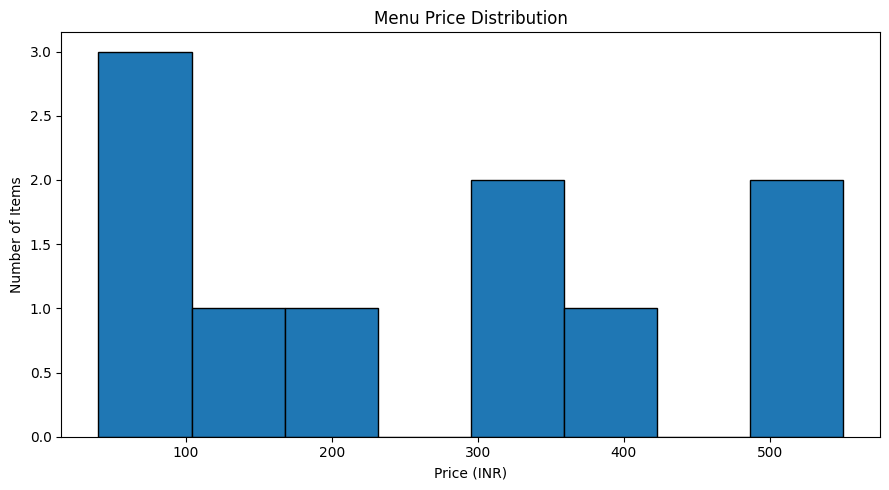

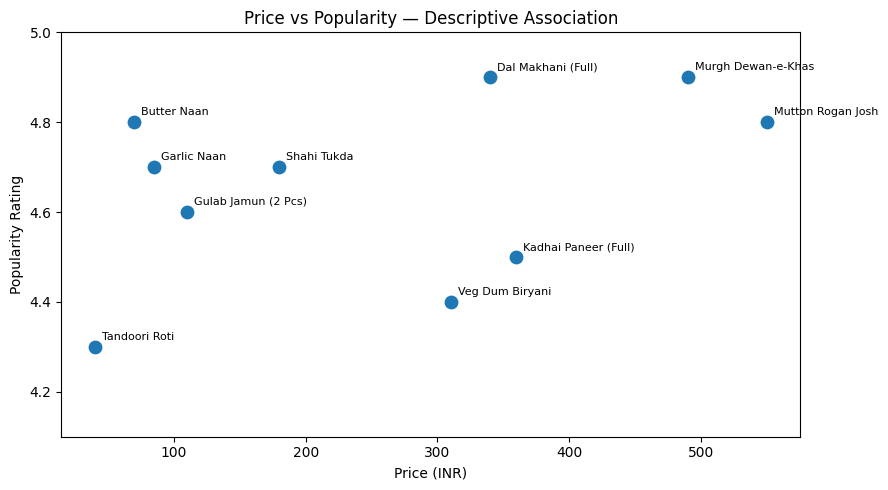

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df["price_inr"], bins=8, edgecolor="black")
ax.set_title("Menu Price Distribution")
ax.set_xlabel("Price (INR)")
ax.set_ylabel("Number of Items")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(df["price_inr"], df["popularity_rating"], s=80)
for _, r in df.iterrows():
    ax.annotate(r["item_name"], (r["price_inr"], r["popularity_rating"]),
                xytext=(5, 5), textcoords="offset points", fontsize=8)
ax.set_title("Price vs Popularity — Descriptive Association")
ax.set_xlabel("Price (INR)")
ax.set_ylabel("Popularity Rating")
ax.set_ylim(4.1, 5.0)
plt.tight_layout()
plt.show()


## 6. Price–Popularity Relationship (Descriptive Only)

This is an observational cross-sectional association across the 10 menu items. It is **not** a price-elasticity estimate and should not be interpreted causally.


In [6]:
pearson_r = df["price_inr"].corr(df["popularity_rating"], method="pearson")
spearman_r = df["price_inr"].corr(df["popularity_rating"], method="spearman")

association = pd.DataFrame({
    "Measure": ["Pearson correlation", "Spearman rank correlation"],
    "Value": [pearson_r, spearman_r],
    "Interpretation": [
        "Linear association across menu items; not causal.",
        "Rank association across menu items; not causal."
    ]
})
display(association)


,Measure,Value,Interpretation
0,Pearson correlation,0.41,Linear association across menu items; not causal.
1,Spearman rank correlation,0.45,Rank association across menu items; not causal.


## 7. Item-Level Commercial Proxies

These metrics describe the menu only. They are **not margin measures** because ingredient costs are unavailable.


In [7]:
df["price_per_100_kcal"] = df["price_inr"] / df["calories_kcal"] * 100
df["price_per_minute_prep"] = df["price_inr"] / df["preparation_time_mins"]

item_metrics = df[[
    "item_id","item_name","category","price_inr","popularity_rating",
    "calories_kcal","preparation_time_mins","chef_special",
    "price_per_100_kcal","price_per_minute_prep"
]].sort_values(["category","price_inr"], ascending=[True,False])

display(item_metrics)


,item_id,item_name,category,price_inr,popularity_rating,calories_kcal,preparation_time_mins,chef_special,price_per_100_kcal,price_per_minute_prep
6,NID-207,Veg Dum Biryani,Breads & Rice,310,4.40,520,20,No,59.62,15.50
2,NID-203,Garlic Naan,Breads & Rice,85,4.70,230,8,No,36.96,10.62
1,NID-202,Butter Naan,Breads & Rice,70,4.80,220,8,No,31.82,8.75
9,NID-210,Tandoori Roti,Breads & Rice,40,4.30,120,5,No,33.33,8.00
7,NID-208,Shahi Tukda,Desserts & Beverages,180,4.70,420,15,Yes,42.86,12.00
8,NID-209,Gulab Jamun (2 Pcs),Desserts & Beverages,110,4.60,310,10,No,35.48,11.00
5,NID-206,Mutton Rogan Josh,Main Course,550,4.80,610,25,Yes,90.16,22.00
4,NID-205,Murgh Dewan-e-Khas,Main Course,490,4.90,580,22,Yes,84.48,22.27
3,NID-204,Kadhai Paneer (Full),Main Course,360,4.50,410,18,No,87.80,20.00
0,NID-201,Dal Makhani (Full),Main Course,340,4.90,450,25,Yes,75.56,13.60


## 8. Competitive Benchmark

The competitor profile supplied for this project reports **segment-level seasonal price corridors**. These are not exact like-for-like dish prices.


In [8]:
# Source: Restaurant Competitor Pricing Profile.pdf — The Oasis Rooftop Lounge
competitor = pd.DataFrame([
  {
    "competitor_segment": "Appetizers & Tapas",
    "peak_min_inr": 450,
    "peak_max_inr": 750,
    "off_min_inr": 300,
    "off_max_inr": 500,
    "peak_mid_inr": 600.0,
    "off_mid_inr": 400.0,
    "peak_to_off_midpoint_change_pct": 50.0
  },
  {
    "competitor_segment": "Main Course",
    "peak_min_inr": 850,
    "peak_max_inr": 1600,
    "off_min_inr": 600,
    "off_max_inr": 1100,
    "peak_mid_inr": 1225.0,
    "off_mid_inr": 850.0,
    "peak_to_off_midpoint_change_pct": 44.11764705882353
  },
  {
    "competitor_segment": "Signature Cocktails",
    "peak_min_inr": 650,
    "peak_max_inr": 950,
    "off_min_inr": 450,
    "off_max_inr": 600,
    "peak_mid_inr": 800.0,
    "off_mid_inr": 525.0,
    "peak_to_off_midpoint_change_pct": 52.38095238095237
  },
  {
    "competitor_segment": "Desserts & Artisanal Coffee",
    "peak_min_inr": 400,
    "peak_max_inr": 600,
    "off_min_inr": 250,
    "off_max_inr": 400,
    "peak_mid_inr": 500.0,
    "off_mid_inr": 325.0,
    "peak_to_off_midpoint_change_pct": 53.846153846153854
  }
])

# Recalculate derived fields to keep the model auditable.
competitor["peak_mid_inr"] = competitor[["peak_min_inr","peak_max_inr"]].mean(axis=1)
competitor["off_mid_inr"] = competitor[["off_min_inr","off_max_inr"]].mean(axis=1)
competitor["peak_to_off_midpoint_change_pct"] = (
    competitor["peak_mid_inr"] / competitor["off_mid_inr"] - 1
) * 100

display(competitor)


,competitor_segment,peak_min_inr,peak_max_inr,off_min_inr,off_max_inr,peak_mid_inr,off_mid_inr,peak_to_off_midpoint_change_pct
0,Appetizers & Tapas,450,750,300,500,600.00,400.00,50.00
1,Main Course,850,1600,600,1100,"1,225.00",850.00,44.12
2,Signature Cocktails,650,950,450,600,800.00,525.00,52.38
3,Desserts & Artisanal Coffee,400,600,250,400,500.00,325.00,53.85


## 9. Comparable Category Positioning

Only these company categories have a defensible mapping to the supplied competitor segments:
- **Main Course → Main Course**
- **Desserts & Beverages → Desserts & Artisanal Coffee**

**Breads & Rice** is retained in the company analysis but excluded from competitor price-gap calculations because the supplied competitor profile does not provide a directly comparable segment.


In [9]:
category_mapping = {
    "Main Course": "Main Course",
    "Desserts & Beverages": "Desserts & Artisanal Coffee"
}

df["competitor_segment"] = df["category"].map(category_mapping)

company_category = (
    df[df["competitor_segment"].notna()]
      .groupby(["category","competitor_segment"], as_index=False)
      .agg(
          company_items=("item_id","count"),
          company_avg_price_inr=("price_inr","mean"),
          company_median_price_inr=("price_inr","median"),
          company_avg_popularity=("popularity_rating","mean")
      )
)

bench = competitor.set_index("competitor_segment")

company_category["competitor_peak_mid_inr"] = company_category["competitor_segment"].map(bench["peak_mid_inr"])
company_category["competitor_off_mid_inr"] = company_category["competitor_segment"].map(bench["off_mid_inr"])

company_category["gap_vs_peak_mid_pct"] = (
    company_category["company_avg_price_inr"] /
    company_category["competitor_peak_mid_inr"] - 1
) * 100

company_category["gap_vs_off_mid_pct"] = (
    company_category["company_avg_price_inr"] /
    company_category["competitor_off_mid_inr"] - 1
) * 100

display(company_category)


,category,competitor_segment,company_items,company_avg_price_inr,company_median_price_inr,company_avg_popularity,competitor_peak_mid_inr,competitor_off_mid_inr,gap_vs_peak_mid_pct,gap_vs_off_mid_pct
0,Desserts & Beverages,Desserts & Artisanal Coffee,2,145.00,145.00,4.65,500.00,325.00,-71.00,-55.38
1,Main Course,Main Course,4,435.00,425.00,4.78,"1,225.00",850.00,-64.49,-48.82


## 10. Competitor Seasonality Architecture

The competitor profile describes a winter peak period (Nov–Feb) and summer off-season period (May–Aug), with different price corridors and promotion mechanics. The midpoint change below is a **mathematical calculation from the supplied ranges**, not a stated competitor discount rate.


,competitor_segment,peak_mid_inr,off_mid_inr,peak_to_off_midpoint_change_pct
0,Appetizers & Tapas,600.00,400.00,50.00
1,Main Course,"1,225.00",850.00,44.12
2,Signature Cocktails,800.00,525.00,52.38
3,Desserts & Artisanal Coffee,500.00,325.00,53.85


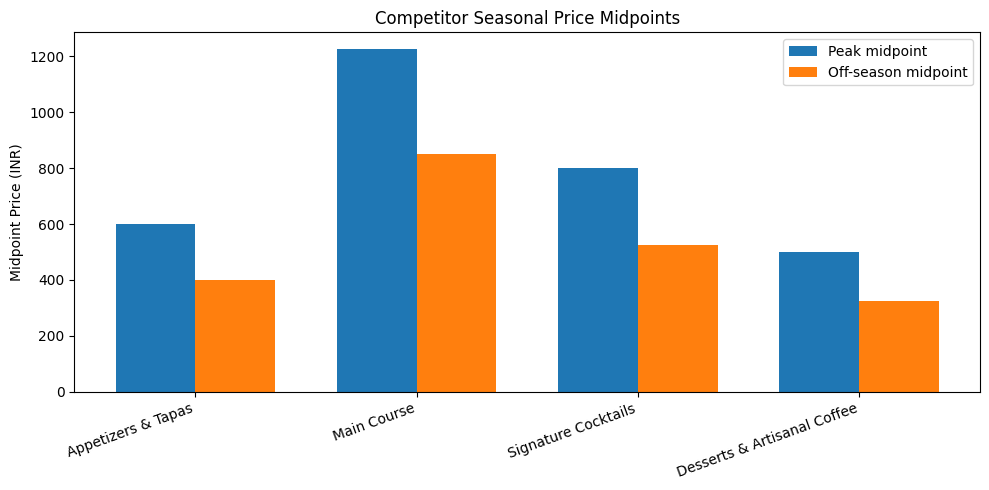

In [10]:
seasonality = competitor[[
    "competitor_segment","peak_mid_inr","off_mid_inr","peak_to_off_midpoint_change_pct"
]].copy()

display(seasonality)

plot_df = seasonality.melt(
    id_vars="competitor_segment",
    value_vars=["peak_mid_inr","off_mid_inr"],
    var_name="season",
    value_name="mid_price"
)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(plot_df["competitor_segment"].unique()))
segments = list(plot_df["competitor_segment"].unique())
width = 0.36

peak_vals = [seasonality.loc[seasonality["competitor_segment"]==s,"peak_mid_inr"].iloc[0] for s in segments]
off_vals = [seasonality.loc[seasonality["competitor_segment"]==s,"off_mid_inr"].iloc[0] for s in segments]

ax.bar(x-width/2, peak_vals, width, label="Peak midpoint")
ax.bar(x+width/2, off_vals, width, label="Off-season midpoint")
ax.set_xticks(x)
ax.set_xticklabels(segments, rotation=20, ha="right")
ax.set_ylabel("Midpoint Price (INR)")
ax.set_title("Competitor Seasonal Price Midpoints")
ax.legend()
plt.tight_layout()
plt.show()


## 11. Promotion Architecture & Commercial Implications

The following statements are taken from the supplied competitor profile. They are benchmark observations, **not measured effects for the company menu**.


In [11]:
promotion_framework = pd.DataFrame([
    ["Peak season", "Premium positioning; limited promotions except premium New Year packages",
     "Protect price integrity; use selective packages rather than assuming blanket discounting is required."],
    ["Off-season", "₹599 weekday lunch; Buy-1-Get-1 domestic-spirit promotion; stronger value mechanics",
     "Use controlled value offers as test hypotheses and measure incremental demand."],
    ["Digital delivery — peak", "Reported 15% premium over dine-in",
     "Treat channel pricing as a separate test variable rather than mixing it with dine-in price."],
    ["Digital delivery — off-season", "Reported premium waived; online bundles/free-delivery offers",
     "Test channel-specific bundles where physical capacity is underutilized."]
], columns=["Context","Competitor benchmark observation","Analytical implication"])

display(promotion_framework)


,Context,Competitor benchmark observation,Analytical implication
0,Peak season,Premium positioning; limited promotions except...,Protect price integrity; use selective package...
1,Off-season,₹599 weekday lunch; Buy-1-Get-1 domestic-spiri...,Use controlled value offers as test hypotheses...
2,Digital delivery — peak,Reported 15% premium over dine-in,Treat channel pricing as a separate test varia...
3,Digital delivery — off-season,Reported premium waived; online bundles/free-d...,Test channel-specific bundles where physical c...


## 12. Item-Level Test Prioritisation

Because there is no historical demand response, this section identifies **what to test**, not what will happen. The rules use the item's popularity and its relative price position within its own category.


In [12]:
df["category_price_percentile"] = df.groupby("category")["price_inr"].rank(pct=True, method="average")

def hypothesis(row):
    high_pop = row["popularity_rating"] >= 4.7
    low_pop = row["popularity_rating"] < 4.5
    upper_half_price = row["category_price_percentile"] > 0.50
    lower_half_price = row["category_price_percentile"] <= 0.50

    if high_pop and lower_half_price:
        return "Controlled premium-positioning test"
    if high_pop and upper_half_price:
        return "Price-hold / small-step pricing test"
    if low_pop and upper_half_price:
        return "Targeted promotion or bundle test"
    if low_pop and lower_half_price:
        return "Visibility / bundle test"
    return "Monitor and collect transaction data"

df["analytical_action"] = df.apply(hypothesis, axis=1)

# A transparent index for prioritizing experiments; this is not a prediction model.
pop_min, pop_max = df["popularity_rating"].min(), df["popularity_rating"].max()
prep_min, prep_max = df["preparation_time_mins"].min(), df["preparation_time_mins"].max()

df["popularity_norm"] = (df["popularity_rating"] - pop_min) / (pop_max - pop_min) if pop_max != pop_min else 0.5
df["prep_norm"] = (df["preparation_time_mins"] - prep_min) / (prep_max - prep_min) if prep_max != prep_min else 0.5
df["chef_special_flag"] = df["chef_special"].str.lower().eq("yes").astype(int)

df["test_priority_index"] = (
    0.50 * df["popularity_norm"] +
    0.20 * df["chef_special_flag"] +
    0.15 * df["prep_norm"] +
    0.15 * df["category_price_percentile"]
) * 100

priority = df[[
    "item_id","item_name","category","price_inr","popularity_rating",
    "chef_special","category_price_percentile","test_priority_index","analytical_action"
]].sort_values("test_priority_index", ascending=False)

display(priority)


,item_id,item_name,category,price_inr,popularity_rating,chef_special,category_price_percentile,test_priority_index,analytical_action
4,NID-205,Murgh Dewan-e-Khas,Main Course,490,4.90,Yes,0.75,94.00,Price-hold / small-step pricing test
5,NID-206,Mutton Rogan Josh,Main Course,550,4.80,Yes,1.00,91.67,Price-hold / small-step pricing test
0,NID-201,Dal Makhani (Full),Main Course,340,4.90,Yes,0.25,88.75,Controlled premium-positioning test
7,NID-208,Shahi Tukda,Desserts & Beverages,180,4.70,Yes,1.00,75.83,Price-hold / small-step pricing test
1,NID-202,Butter Naan,Breads & Rice,70,4.80,No,0.50,51.42,Controlled premium-positioning test
2,NID-203,Garlic Naan,Breads & Rice,85,4.70,No,0.75,46.83,Price-hold / small-step pricing test
8,NID-209,Gulab Jamun (2 Pcs),Desserts & Beverages,110,4.60,No,0.50,36.25,Monitor and collect transaction data
6,NID-207,Veg Dum Biryani,Breads & Rice,310,4.40,No,1.00,34.58,Targeted promotion or bundle test
3,NID-204,Kadhai Paneer (Full),Main Course,360,4.50,No,0.50,33.92,Monitor and collect transaction data
9,NID-210,Tandoori Roti,Breads & Rice,40,4.30,No,0.25,3.75,Visibility / bundle test


## 13. Experiment Design & Measurement

A proper pricing/promotion decision requires transaction-level measurement. The following framework is the recommended measurement structure, not a claimed result.


In [13]:
experiment_design = pd.DataFrame([
    ["Price test", "Comparable menu item / matched periods", "Listed price", "Units sold, revenue, average check", "Hold promotion/channel constant"],
    ["Promotion test", "Comparable customer/time segments", "Promotion exposure", "Incremental units, revenue, contribution margin", "Keep base price stable"],
    ["Bundle test", "Comparable periods or randomized exposure", "Bundle offer", "Bundle uptake, average check, contribution margin", "Track cannibalization"],
    ["Channel test", "Dine-in vs delivery", "Channel price / bundle", "Channel mix, revenue, contribution margin", "Control for availability/capacity"],
    ["Season test", "Same item across seasons", "Seasonal price/offer", "Units, revenue, margin, footfall", "Record season and external demand drivers"]
], columns=["Experiment","Comparison structure","Primary treatment","Primary outcomes","Key control"])

display(experiment_design)


,Experiment,Comparison structure,Primary treatment,Primary outcomes,Key control
0,Price test,Comparable menu item / matched periods,Listed price,"Units sold, revenue, average check",Hold promotion/channel constant
1,Promotion test,Comparable customer/time segments,Promotion exposure,"Incremental units, revenue, contribution margin",Keep base price stable
2,Bundle test,Comparable periods or randomized exposure,Bundle offer,"Bundle uptake, average check, contribution margin",Track cannibalization
3,Channel test,Dine-in vs delivery,Channel price / bundle,"Channel mix, revenue, contribution margin",Control for availability/capacity
4,Season test,Same item across seasons,Seasonal price/offer,"Units, revenue, margin, footfall",Record season and external demand drivers


## 14. Data Roadmap for the Next-Stage Model

This is intentionally separated from the current analysis. It defines the data required before claiming elasticity or optimization.


In [14]:
required_transaction_fields = pd.DataFrame([
    ["date", "Transaction date"],
    ["item_id", "Menu item identifier"],
    ["listed_price_inr", "Price before discount"],
    ["discount_inr", "Discount amount"],
    ["promotion_id", "Promotion / campaign identifier"],
    ["units_sold", "Units sold"],
    ["revenue_inr", "Realized revenue"],
    ["channel", "Dine-in / delivery / takeaway"],
    ["day_of_week", "Calendar effect"],
    ["season", "Peak / off-season"],
    ["footfall_or_covers", "Demand intensity control"],
    ["weather_or_event", "External demand control"],
    ["unit_cost_inr", "Contribution-margin input"]
], columns=["Field","Purpose"])

display(required_transaction_fields)

print("Future demand model form:")
print("Units_Sold = f(Price, Promotion, Season, Day, Item, Channel, Footfall, Weather/Event, ...)")
print("Price elasticity = % change in quantity / % change in price")
print("Expected Profit(price) = Expected Units(price) × (price − unit_cost)")


,Field,Purpose
0,date,Transaction date
1,item_id,Menu item identifier
2,listed_price_inr,Price before discount
3,discount_inr,Discount amount
4,promotion_id,Promotion / campaign identifier
5,units_sold,Units sold
6,revenue_inr,Realized revenue
7,channel,Dine-in / delivery / takeaway
8,day_of_week,Calendar effect
9,season,Peak / off-season


Future demand model form:
Units_Sold = f(Price, Promotion, Season, Day, Item, Channel, Footfall, Weather/Event, ...)
Price elasticity = % change in quantity / % change in price
Expected Profit(price) = Expected Units(price) × (price − unit_cost)


## 15. Executive Management Summary

The cell below generates concise findings directly from the calculated outputs, so the narrative stays synchronized with the data.


In [15]:
print("MANAGEMENT SUMMARY")
print("=" * 80)

print(f"• Menu scope: {len(df)} items across {df['category'].nunique()} categories.")
print(f"• Price range: ₹{df['price_inr'].min():,.0f}–₹{df['price_inr'].max():,.0f}; average ₹{df['price_inr'].mean():,.0f}.")
print(f"• Average popularity rating: {df['popularity_rating'].mean():.2f}/5.")
print(f"• Price/popularity Pearson association: {pearson_r:.3f}; this is cross-sectional and non-causal.")

for _, r in company_category.iterrows():
    print(
        f"• {r['category']}: company average ₹{r['company_avg_price_inr']:,.0f} "
        f"vs supplied competitor {r['competitor_segment']} peak midpoint ₹{r['competitor_peak_mid_inr']:,.0f} "
        f"and off-season midpoint ₹{r['competitor_off_mid_inr']:,.0f}."
    )

print("• Competitor benchmark is segment-level; Breads & Rice is not assigned a direct competitor segment.")
print("• Promotion recommendations are test hypotheses because promotion-response history is unavailable.")
print("• No causal price elasticity or profit-optimal price is estimated from this dataset.")


MANAGEMENT SUMMARY
• Menu scope: 10 items across 3 categories.
• Price range: ₹40–₹550; average ₹254.
• Average popularity rating: 4.66/5.
• Price/popularity Pearson association: 0.405; this is cross-sectional and non-causal.
• Desserts & Beverages: company average ₹145 vs supplied competitor Desserts & Artisanal Coffee peak midpoint ₹500 and off-season midpoint ₹325.
• Main Course: company average ₹435 vs supplied competitor Main Course peak midpoint ₹1,225 and off-season midpoint ₹850.
• Competitor benchmark is segment-level; Breads & Rice is not assigned a direct competitor segment.
• Promotion recommendations are test hypotheses because promotion-response history is unavailable.
• No causal price elasticity or profit-optimal price is estimated from this dataset.


## 16. Model QA & Control Checks

This section is designed to fail loudly if the final notebook is accidentally altered or produces invalid analytical outputs.


In [16]:
# Structural QA
expected_columns = {
    "item_id","item_name","category","sub_category","description","price_inr",
    "spice_level","dietary_indicator","portion_size","calories_kcal","allergens",
    "preparation_time_mins","chef_special","popularity_rating","primary_ingredients"
}
assert set(company_records[0].keys()) == expected_columns, "Source schema mismatch."
assert len(company_records) == 10, f"Unexpected source row count: {len(company_records)}"
assert len(expected_columns) == 15, "Expected source schema must contain 15 variables."
assert set(df.columns[:15]) == expected_columns, "Source columns were not preserved."
assert df["item_id"].is_unique, "Item IDs must be unique."
assert df["price_inr"].notna().all() and (df["price_inr"] > 0).all()
assert df["popularity_rating"].between(0,5).all()
assert df["preparation_time_mins"].gt(0).all()

# Analytical QA
assert len(competitor) == 4
assert (competitor["peak_max_inr"] >= competitor["peak_min_inr"]).all()
assert (competitor["off_max_inr"] >= competitor["off_min_inr"]).all()
assert company_category["competitor_peak_mid_inr"].notna().all()
assert np.isfinite(df["test_priority_index"]).all()
assert df["analytical_action"].notna().all()

print("ALL FINAL QA CHECKS: PASS")
print("No manual edits are required for the analytical workflow.")


ALL FINAL QA CHECKS: PASS
No manual edits are required for the analytical workflow.


## 17. Deliverables & Analytical Exports

The notebook automatically creates the final deliverables in the Colab working directory. No code changes are required.


In [17]:
# Build clean export tables
clean_menu = df.copy()

# Keep raw/derived fields together for reproducibility.
priority_export = priority.copy()
category_export = company_category.copy()
seasonality_export = seasonality.copy()
promotion_export = promotion_framework.copy()
experiment_export = experiment_design.copy()
qa_export = pd.DataFrame({
    "check": [
        "Source rows", "Source columns", "Duplicate rows", "Duplicate item IDs",
        "Missing values after cleaning", "QA status"
    ],
    "result": [
        len(df), 15, int(df.duplicated().sum()), int(df["item_id"].duplicated().sum()),
        int(df.isna().sum().sum()), "PASS"
    ]
})

csv_path = "restaurant_pricing_analytics_final_enriched.csv"
xlsx_path = "Restaurant_Pricing_Promotion_Analytics_FINAL.xlsx"

clean_menu.to_csv(csv_path, index=False)

with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
    clean_menu.to_excel(writer, sheet_name="Enriched Menu", index=False)
    category_export.to_excel(writer, sheet_name="Category Benchmark", index=False)
    competitor.to_excel(writer, sheet_name="Competitor Benchmark", index=False)
    seasonality_export.to_excel(writer, sheet_name="Seasonality", index=False)
    promotion_export.to_excel(writer, sheet_name="Promotion Framework", index=False)
    priority_export.to_excel(writer, sheet_name="Test Priorities", index=False)
    experiment_export.to_excel(writer, sheet_name="Experiment Design", index=False)
    qa_export.to_excel(writer, sheet_name="QA", index=False)

print(f"Created: {csv_path}")
print(f"Created: {xlsx_path}")


Created: restaurant_pricing_analytics_final_enriched.csv
Created: Restaurant_Pricing_Promotion_Analytics_FINAL.xlsx


## 18. Final Business-Analyst Conclusion

**Recommended project title:**  
### Restaurant Pricing & Promotion Analytics — Decision-Support Model

**What can be claimed**
- The model provides descriptive menu analytics.
- It quantifies cross-sectional price/popularity association.
- It benchmarks comparable company categories against the supplied competitor's published price corridors.
- It translates the competitor's documented seasonal and promotional mechanics into testable marketing hypotheses.
- It provides a transparent rule-based prioritization index for experiments.

**What should not be claimed**
- A causal price elasticity estimate.
- A demand forecast.
- A profit-maximizing price.
- A measured uplift from promotions.
- A machine-learning prediction model trained on this menu master.

Those claims require transaction-level observations and margin data.

**Submission status:** The notebook is designed to run top-to-bottom without manual code modification. The company and competitor source inputs are embedded for reproducibility.
